In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as py

In [15]:
df = pd.read_csv("trusted/tv_shows_trusted.csv")
df

,ID,Title,Year,Age,Netflix,Hulu,Prime Video,Disney+,imdb_100,rottenTomatoes_100
0,1,Breaking Bad,2008,18+,SIM,NÃO,NÃO,NÃO,94.0,100.0
1,2,Stranger Things,2016,16+,SIM,NÃO,NÃO,NÃO,87.0,96.0
2,3,Attack on Titan,2013,18+,SIM,SIM,NÃO,NÃO,90.0,95.0
3,4,Better Call Saul,2015,18+,SIM,NÃO,NÃO,NÃO,88.0,94.0
4,5,Dark,2017,16+,SIM,NÃO,NÃO,NÃO,88.0,93.0
...,...,...,...,...,...,...,...,...,...,...
3202,5684,Disney Family Sundays,2019,all,NÃO,NÃO,NÃO,SIM,56.0,31.0
3203,5687,Wild Chile,2018,7+,NÃO,NÃO,NÃO,SIM,75.0,30.0
3204,5688,Howie Mandel's Animals Doing Things,2018,all,NÃO,NÃO,NÃO,SIM,32.0,30.0
3205,5690,The Big Fib,2020,all,NÃO,NÃO,NÃO,SIM,54.0,29.0


Para qual público alvo as séries são mais produzidas?

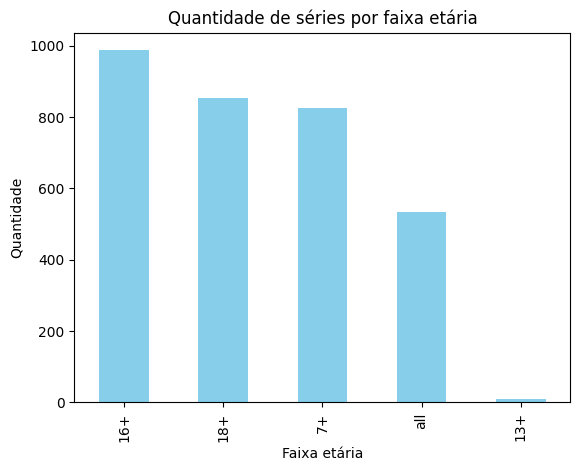

In [16]:
plt.figure()
df['Age'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Faixa etária')
plt.ylabel('Quantidade')
plt.title('Quantidade de séries por faixa etária')

plt.savefig('refined/qtdFaixaEtaria.png', bbox_inches='tight')
plt.show()
plt.close()

Com este gráfico podemos visualizar a quantidade de filmes por faixa etária, onde conseguimos perceber que a nossa beneficiária pode focar suas produções de artesanatos de séries para toda a familia e maiores de 16 anos.
Assim, ela consegue focar e direcionar temas de séries utilizando campanhas que funcionem para determinados públicos.

Qual plataforma tem um catálogo maior para busca de referências e inspirações de temas para produtos?

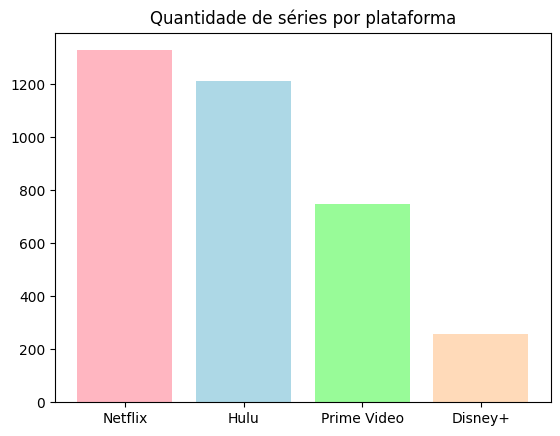

In [17]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

counts = []
for p in platforms:
    counts.append(df[df[p] == 'SIM'].shape[0])

plt.figure()
plt.bar(platforms, counts, color=['#FFB6C1', '#ADD8E6', '#98FB98', '#FFDAB9'])
plt.title('Quantidade de séries por plataforma')

plt.savefig('refined/qtdPorPlataforma.png', bbox_inches='tight')
plt.show()
plt.close()

Caso a beneficiária faça uma análise de plataformas para referência de temas, ela consegue visualizar por volume de conteudo dentro da plataforma, buscando a plataforma que tem mais series disponibilizadas para buscar referencias e inspiracoes

Qual critica levar em avaliação quando buscar as series mais bem avaliadas?

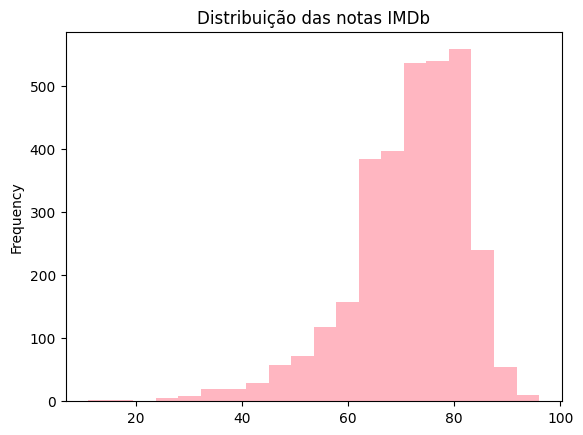

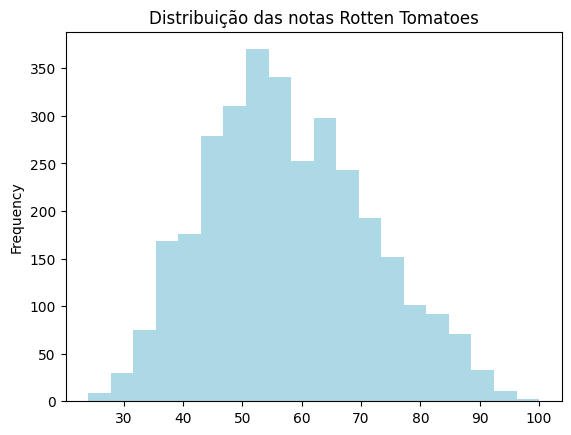

In [18]:
df['score'] = df[['imdb_100']].mean(axis=1)

plt.figure()
df['score'].plot(kind='hist', bins=20, color='#FFB6C1')
plt.title('Distribuição das notas IMDb')
plt.savefig('refined/distribuicaoIMDb.png', bbox_inches='tight')
plt.show()

df['score'] = df[['rottenTomatoes_100']].mean(axis=1)

plt.figure()
df['score'].plot(kind='hist', bins=20, color='#ADD8E6')
plt.title('Distribuição das notas Rotten Tomatoes')
plt.savefig('refined/distribuicaoRotten.png', bbox_inches='tight')
plt.show()
plt.close()

Nesta analise, podemos observar que o publico (IMDb) costuma dar notas mais altas do que a critica profissional (Rotten Tomatoes), o público geral tem o costume de avaliar melhor e pode considerar mais a compra de produtos com as series que ele gosta

Quais temas de series podem ser melhor aproveitados para o publico adulto e infantil?

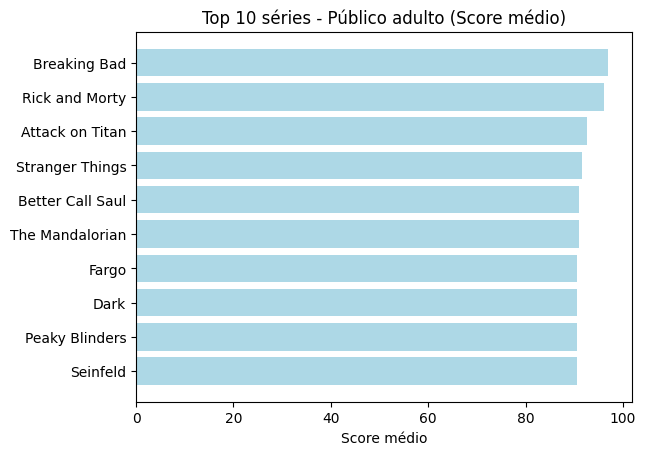

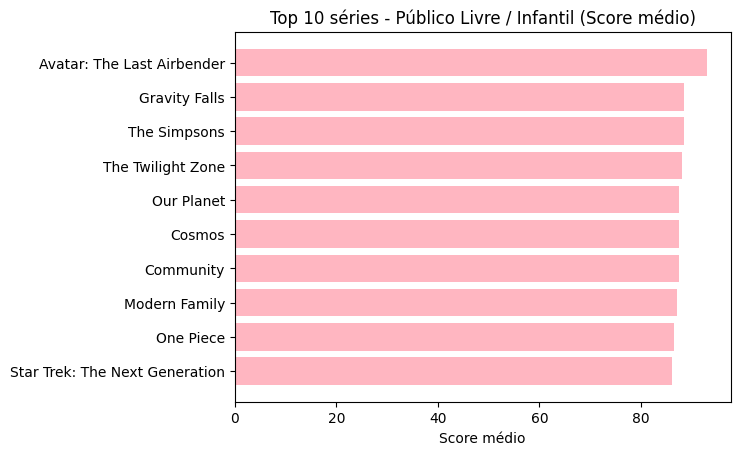

In [19]:
adulto = df[df['Age'].isin(['16+', '18+'])].copy()
adulto['score'] = adulto[['imdb_100', 'rottenTomatoes_100']].mean(axis=1)
top10_adulto = adulto.sort_values('score', ascending=False).head(10)
plt.figure()
plt.barh(top10_adulto['Title'], top10_adulto['score'], color='#ADD8E6')
plt.gca().invert_yaxis()
plt.title('Top 10 séries - Público adulto (Score médio)')
plt.xlabel('Score médio')
plt.savefig('refined/top10_adulto.png', bbox_inches='tight')
plt.show()

infantil = df[df['Age'].isin(['all', '7+', '13+'])].copy()
infantil['score'] = infantil[['imdb_100', 'rottenTomatoes_100']].mean(axis=1)
top10_infantil = infantil.sort_values('score', ascending=False).head(10)
plt.figure()
plt.barh(top10_infantil['Title'], top10_infantil['score'], color='#FFB6C1')
plt.gca().invert_yaxis()
plt.title('Top 10 séries - Público Livre / Infantil (Score médio)')
plt.xlabel('Score médio')
plt.savefig('refined/top10_infantil.png', bbox_inches='tight')
plt.show()

Com estes graficos, a beneficiaria consegue considerar as series com uma maior media para produzir seus produtos artesanais, focando no que o publico geral gosta mais

Quais series o publico tem mais acesso por plataformas?

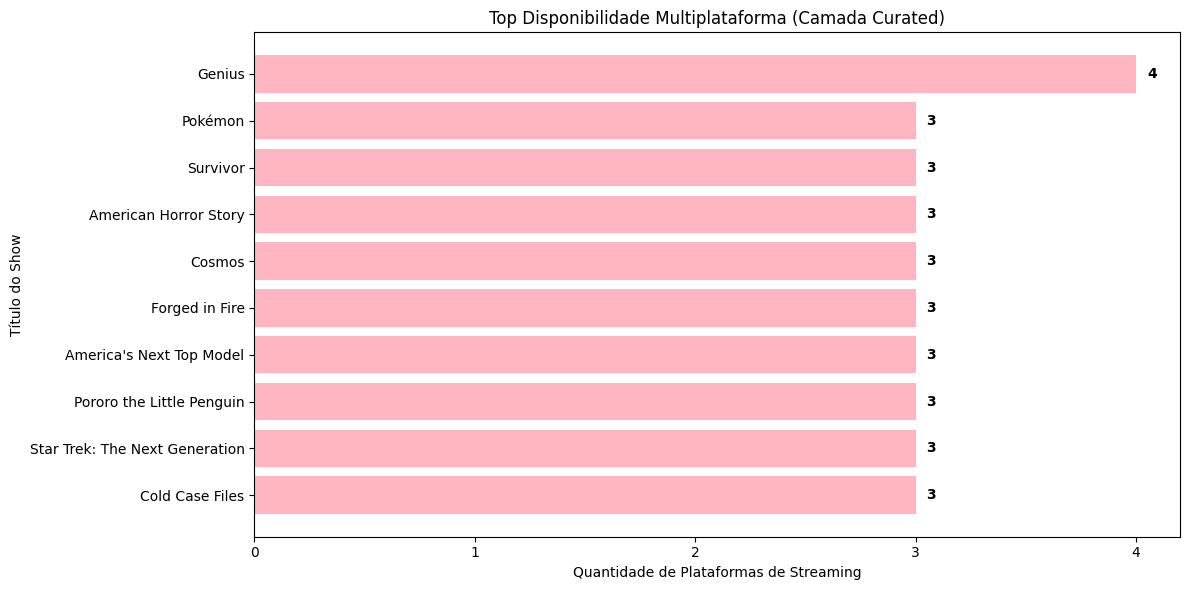

In [20]:
df = pd.read_csv('trusted/tv_shows_trusted.csv')
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

for p in platforms:
    df[p + '_bin'] = (df[p].astype(str).str.strip().str.upper() == 'SIM').astype(int)

df['Total_Plataformas'] = df[[p + '_bin' for p in platforms]].sum(axis=1)

top_disponibilidade = df.sort_values(by='Total_Plataformas', ascending=False).head(10)

plt.figure(figsize=(12, 6))

plt.barh(top_disponibilidade['Title'], top_disponibilidade['Total_Plataformas'], color='#FFB6C1')

plt.title('Top Disponibilidade Multiplataforma (Camada Curated)')
plt.xlabel('Quantidade de Plataformas de Streaming')
plt.ylabel('Título do Show')
plt.gca().invert_yaxis()
plt.xticks([0, 1, 2, 3, 4]) 

for i, v in enumerate(top_disponibilidade['Total_Plataformas']):
    plt.text(v + 0.05, i, f'{int(v)}', va='center', fontweight='bold', color='black')

plt.tight_layout()

plt.savefig('refined/disponibilidadeMultiplataforma.png', bbox_inches='tight')
plt.show()

Nesta analise, podemos ver as series que tem mais capacidade de atingir o publico geral, quanto mais disponibilidade de plataformas, mais pessoas conseguem assistir a serie e se interessar por produtos

Quais temas de series não são relevantes para o publico adulto e infantil?

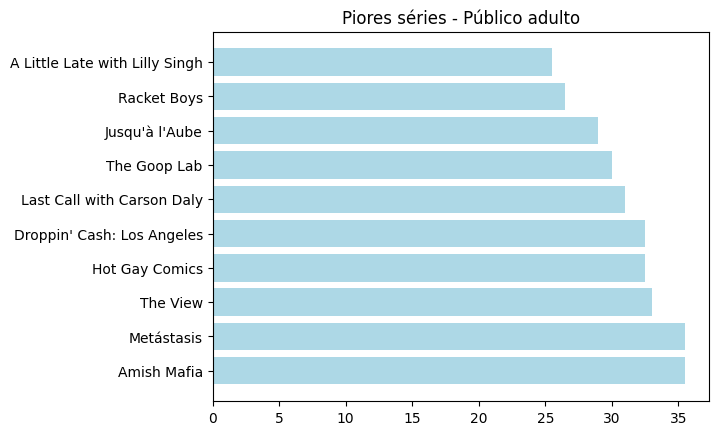

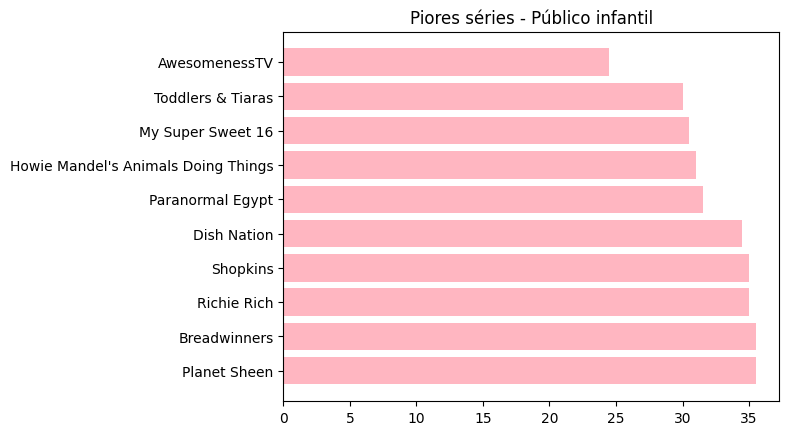

In [21]:
adulto = df[df['Age'].isin(['16+', '18+'])].copy()
adulto['score'] = adulto[['imdb_100','rottenTomatoes_100']].mean(axis=1)

worst_adulto = adulto.sort_values('score').head(10)

plt.figure()
plt.barh(worst_adulto['Title'], worst_adulto['score'], color='#ADD8E6')
plt.gca().invert_yaxis()
plt.title('Piores séries - Público adulto')

plt.savefig('refined/piores_adulto.png', bbox_inches='tight')
plt.show()

infantil = df[df['Age'].isin(['all','7+','13+'])].copy()
infantil['score'] = infantil[['imdb_100','rottenTomatoes_100']].mean(axis=1)

worst_infantil = infantil.sort_values('score').head(10)

plt.figure()
plt.barh(worst_infantil['Title'], worst_infantil['score'], color='#FFB6C1')
plt.gca().invert_yaxis()
plt.title('Piores séries - Público infantil')
plt.savefig('refined/piores_series_infantil.png', bbox_inches='tight')

plt.savefig('refined/piores_infantil.png', bbox_inches='tight')
plt.show()

Com estes graficos, a beneficiaria consegue considerar as series com a menor media para não focar a producao de seus produtos artesanais, focando no que o publico geral tem mais interesse
Tambem consegue visualizar se existem produtos em seu catalogo que pode considerar o arquivamento

Quais são as melhores ou piores séries?

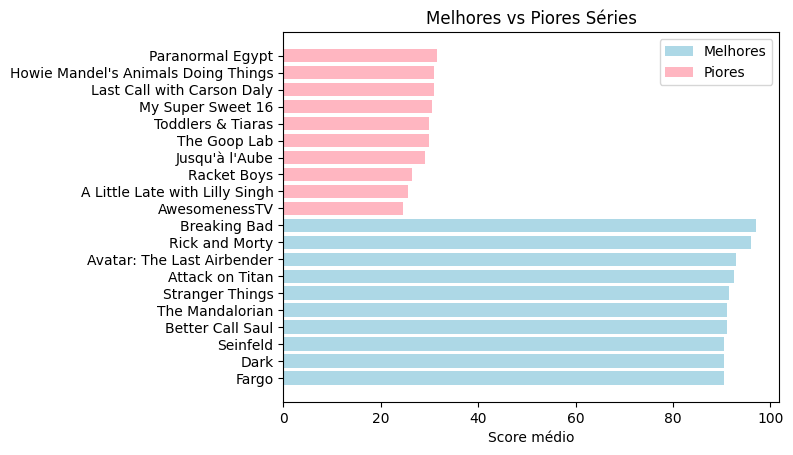

In [22]:
df['score'] = df[['imdb_100','rottenTomatoes_100']].mean(axis=1)

top10 = df.sort_values('score', ascending=False).head(10)
worst10 = df.sort_values('score', ascending=True).head(10)

top10['tipo'] = 'Melhores'
worst10['tipo'] = 'Piores'

combined = pd.concat([top10, worst10])

combined = combined.sort_values('score')

plt.figure()

for tipo, grupo in combined.groupby('tipo'):
    plt.barh(grupo['Title'], grupo['score'], label=tipo, color='#ADD8E6' if tipo == 'Melhores' else '#FFB6C1')

plt.legend()
plt.title('Melhores vs Piores Séries')
plt.xlabel('Score médio')

plt.savefig('refined/melhores_piores_series.png', bbox_inches='tight')
plt.show()

Com estes graficos, a beneficiaria consegue considerar as series com a menor media ou maior media para focar a producao de seus produtos artesanais, focando no que o publico geral tem mais interesse
Tambem consegue visualizar se existem produtos em seu catalogo que pode considerar o arquivamento

Analítico, faça você mesmo:

In [23]:
from IPython.display import HTML

HTML('<a href="./trusted/tv_shows_trusted.csv" download>Baixar relatório analítico</a>')